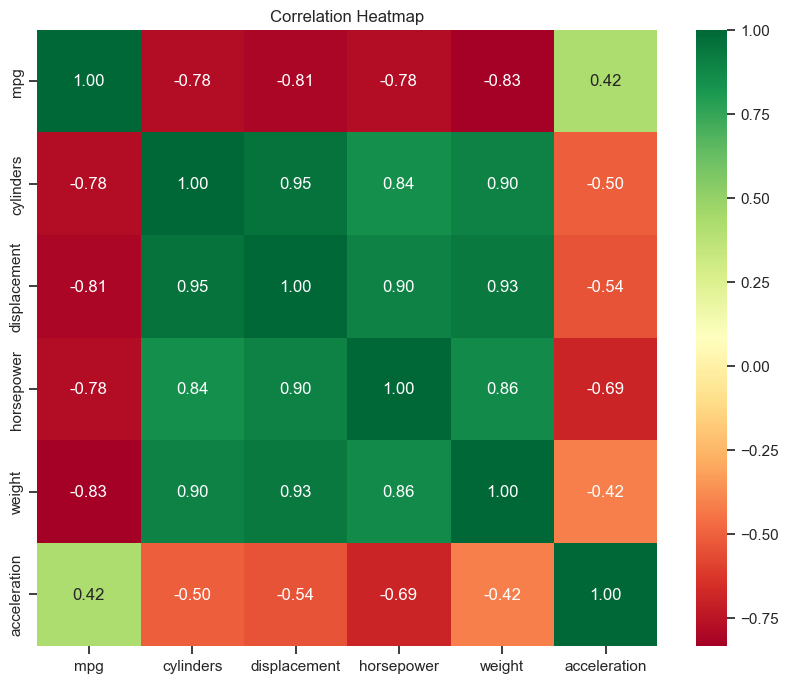

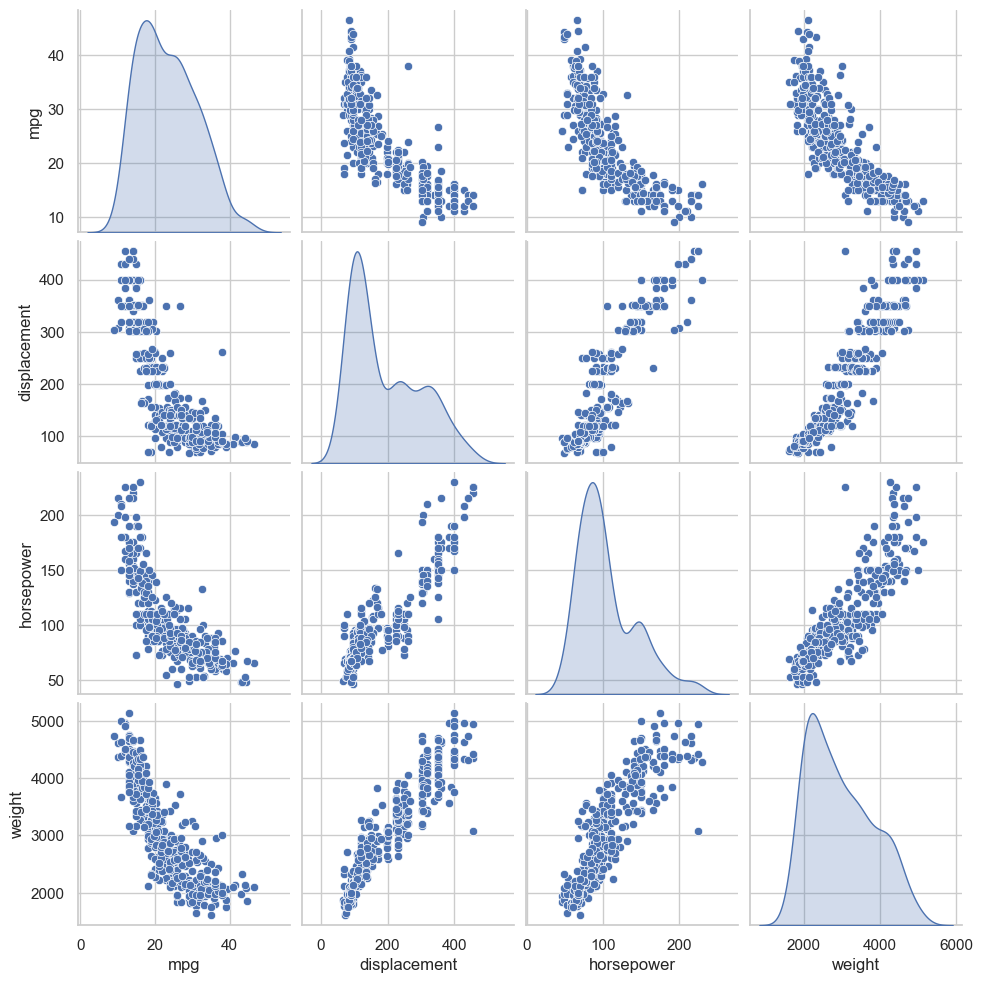

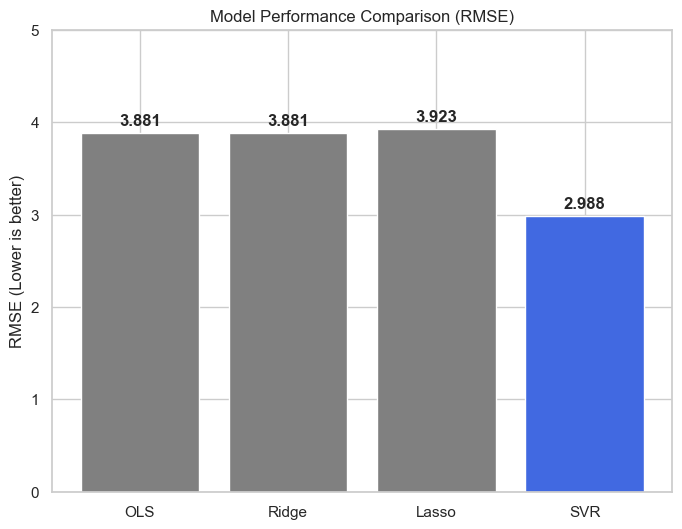

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Định nghĩa tên các cột
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
                'acceleration', 'model_year', 'origin', 'car_name']

# 2. Đọc dữ liệu (LƯU Ý: skiprows=1 để bỏ qua dòng tiêu đề trong file của bạn)
df = pd.read_csv('auto-mpg.data', 
                 skiprows=1, 
                 names=column_names, 
                 na_values='?', 
                 sep='\s+', 
                 skipinitialspace=True)

# 3. Xử lý dữ liệu thiếu và ép kiểu
df = df.dropna(subset=['horsepower'])
df['horsepower'] = df['horsepower'].astype(float)

# 4. TẠO HEATMAP
plt.figure(figsize=(10, 8))
# Chọn các cột số (Sẽ lấy được mpg, cylinders, displacement, horsepower, weight, acceleration)
# Chúng ta bỏ qua origin và model_year để biểu đồ tập trung vào các thông số kỹ thuật
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig('heatmap_corrected.png')
plt.show()

# 5. TẠO PAIRPLOT
sns.set(style="whitegrid")
# Chọn các biến quan trọng nhất để vẽ xu hướng phi tuyến
pair_cols = ['mpg', 'displacement', 'horsepower', 'weight']
sns.pairplot(df[pair_cols], diag_kind='kde')
plt.savefig('pairplot_corrected.png')
plt.show()

# --- HÌNH 3: COMPARISON BAR CHART (So sánh RMSE giữa các mô hình) ---
# Dữ liệu này lấy từ bảng kết quả thực nghiệm của bạn
models = ['OLS', 'Ridge', 'Lasso', 'SVR']
rmse_values = [3.881, 3.881, 3.923, 2.988]

plt.figure(figsize=(8, 6))
colors = ['gray', 'gray', 'gray', 'royalblue'] # Làm nổi bật SVR
bars = plt.bar(models, rmse_values, color=colors)

# Thêm số liệu trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, yval, ha='center', va='bottom', fontweight='bold')

plt.ylabel('RMSE (Lower is better)')
plt.title('Model Performance Comparison (RMSE)')
plt.ylim(0, 5) # Để biểu đồ dễ nhìn hơn
plt.savefig('model_comparison.png')
plt.show()